In [1]:
from pathlib import Path
import json
import warnings

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.colors import LinearSegmentedColormap

warnings.filterwarnings("ignore")

In [2]:
PROJECT_DIR = Path.cwd()

RESULTS_DIR = PROJECT_DIR / "results"
FIGURE_DIR = RESULTS_DIR / "figures"
TABLE_DIR = RESULTS_DIR / "tables"

FINAL_FIGURE_DIR = FIGURE_DIR / "final_summary"
FINAL_TABLE_DIR = TABLE_DIR / "final_summary"

FINAL_FIGURE_DIR.mkdir(parents=True, exist_ok=True)
FINAL_TABLE_DIR.mkdir(parents=True, exist_ok=True)

print("Project directory:", PROJECT_DIR)
print("Final figure directory:", FINAL_FIGURE_DIR)
print("Final table directory:", FINAL_TABLE_DIR)

Project directory: d:\HUST\ET4248E - Học máy trong y tế\Final Project
Final figure directory: d:\HUST\ET4248E - Học máy trong y tế\Final Project\results\figures\final_summary
Final table directory: d:\HUST\ET4248E - Học máy trong y tế\Final Project\results\tables\final_summary


In [4]:
PURPLE_MAIN = "#C599B6"
PURPLE_DARK = "#8A5A78"
PURPLE_MID = "#B77FA0"
PURPLE_LIGHT = "#E8D3DF"
PURPLE_VERY_LIGHT = "#F5EAF1"
GRAY = "#6B6B6B"
RED_SOFT = "#C44E52"

purple_cmap = LinearSegmentedColormap.from_list(
    "custom_purple",
    ["#F8F1F5", "#E8D3DF", "#C599B6", "#8A5A78", "#4A263B"]
)

plt.rcParams["figure.figsize"] = (8, 5)
plt.rcParams["axes.titlesize"] = 15
plt.rcParams["axes.labelsize"] = 12
plt.rcParams["xtick.labelsize"] = 10
plt.rcParams["ytick.labelsize"] = 10
plt.rcParams["font.size"] = 11
plt.rcParams["axes.grid"] = True
plt.rcParams["grid.alpha"] = 0.25

In [3]:
def save_table(df, filename):
    path = FINAL_TABLE_DIR / filename
    df.to_csv(path, index=False, encoding="utf-8-sig")
    print("Saved:", path)
    return path


def save_current_figure(filename):
    path = FINAL_FIGURE_DIR / filename
    plt.tight_layout()
    plt.savefig(path, dpi=300)
    plt.show()
    print("Saved:", path)
    return path

# Final MI Detection Results

In [5]:
record_level_detection_df = pd.DataFrame([
    {
        "setting": "Default SVM RBF decision",
        "level": "Record-level",
        "accuracy": 0.852941,
        "precision_mi": 0.979167,
        "recall_sensitivity_mi": 0.839286,
        "specificity_healthy": 0.916667,
        "f1_mi": 0.903846,
        "macro_f1": 0.795673,
        "balanced_accuracy": 0.877976,
        "roc_auc": 0.937500,
        "tn": 11,
        "fp": 1,
        "fn": 9,
        "tp": 47
    },
    {
        "setting": "Recall-priority threshold",
        "level": "Record-level",
        "accuracy": 0.867647,
        "precision_mi": 0.943396,
        "recall_sensitivity_mi": 0.892857,
        "specificity_healthy": 0.750000,
        "f1_mi": 0.917431,
        "macro_f1": 0.792049,
        "balanced_accuracy": 0.821429,
        "roc_auc": 0.937500,
        "tn": 9,
        "fp": 3,
        "fn": 6,
        "tp": 50
    }
])

display(record_level_detection_df)

save_table(record_level_detection_df, "final_record_level_detection_results.csv")

,setting,level,accuracy,precision_mi,recall_sensitivity_mi,specificity_healthy,f1_mi,macro_f1,balanced_accuracy,roc_auc,tn,fp,fn,tp
0,Default SVM RBF decision,Record-level,0.852941,0.979167,0.839286,0.916667,0.903846,0.795673,0.877976,0.9375,11,1,9,47
1,Recall-priority threshold,Record-level,0.867647,0.943396,0.892857,0.750000,0.917431,0.792049,0.821429,0.9375,9,3,6,50


Saved: d:\HUST\ET4248E - Học máy trong y tế\Final Project\results\tables\final_summary\final_record_level_detection_results.csv


WindowsPath('d:/HUST/ET4248E - Học máy trong y tế/Final Project/results/tables/final_summary/final_record_level_detection_results.csv')

In [6]:
patient_level_detection_df = pd.DataFrame([
    {
        "setting": "SVM RBF patient-level aggregation",
        "level": "Patient-level",
        "accuracy": 0.866667,
        "precision_mi": 0.950000,
        "recall_sensitivity_mi": 0.863636,
        "specificity_healthy": 0.875000,
        "f1_mi": 0.904762,
        "macro_f1": 0.841270,
        "balanced_accuracy": 0.869318,
        "roc_auc": 0.954545,
        "tn": 7,
        "fp": 1,
        "fn": 3,
        "tp": 19
    }
])

display(patient_level_detection_df)

save_table(patient_level_detection_df, "final_patient_level_detection_results.csv")

,setting,level,accuracy,precision_mi,recall_sensitivity_mi,specificity_healthy,f1_mi,macro_f1,balanced_accuracy,roc_auc,tn,fp,fn,tp
0,SVM RBF patient-level aggregation,Patient-level,0.866667,0.95,0.863636,0.875,0.904762,0.84127,0.869318,0.954545,7,1,3,19


Saved: d:\HUST\ET4248E - Học máy trong y tế\Final Project\results\tables\final_summary\final_patient_level_detection_results.csv


WindowsPath('d:/HUST/ET4248E - Học máy trong y tế/Final Project/results/tables/final_summary/final_patient_level_detection_results.csv')

In [7]:
final_detection_summary_df = pd.concat(
    [record_level_detection_df, patient_level_detection_df],
    ignore_index=True
)

display(final_detection_summary_df[
    [
        "setting",
        "level",
        "accuracy",
        "recall_sensitivity_mi",
        "specificity_healthy",
        "macro_f1",
        "roc_auc",
        "tn", "fp", "fn", "tp"
    ]
])

save_table(final_detection_summary_df, "final_detection_summary.csv")

,setting,level,accuracy,recall_sensitivity_mi,specificity_healthy,macro_f1,roc_auc,tn,fp,fn,tp
0,Default SVM RBF decision,Record-level,0.852941,0.839286,0.916667,0.795673,0.937500,11,1,9,47
1,Recall-priority threshold,Record-level,0.867647,0.892857,0.750000,0.792049,0.937500,9,3,6,50
2,SVM RBF patient-level aggregation,Patient-level,0.866667,0.863636,0.875000,0.841270,0.954545,7,1,3,19


Saved: d:\HUST\ET4248E - Học máy trong y tế\Final Project\results\tables\final_summary\final_detection_summary.csv


WindowsPath('d:/HUST/ET4248E - Học máy trong y tế/Final Project/results/tables/final_summary/final_detection_summary.csv')

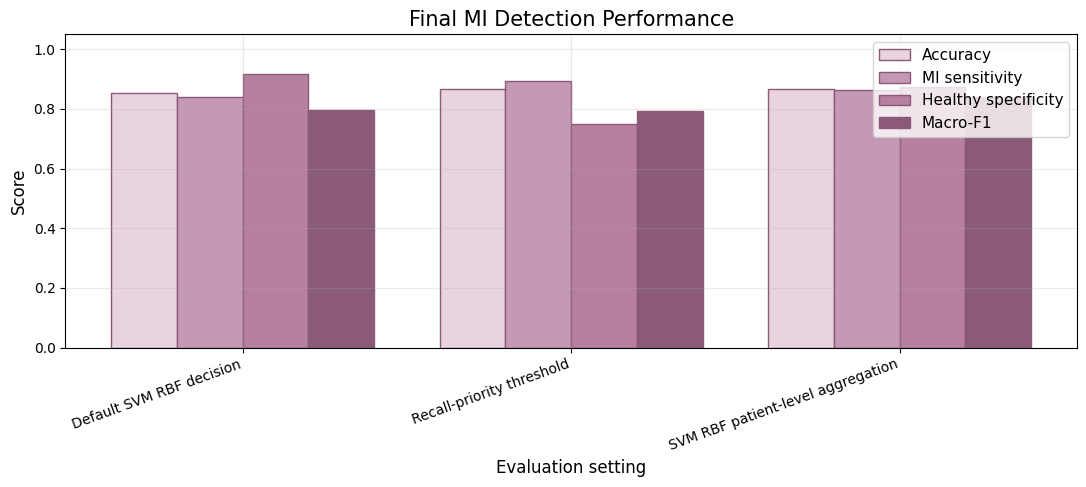

Saved: d:\HUST\ET4248E - Học máy trong y tế\Final Project\results\figures\final_summary\final_mi_detection_performance.png


WindowsPath('d:/HUST/ET4248E - Học máy trong y tế/Final Project/results/figures/final_summary/final_mi_detection_performance.png')

In [8]:
plot_df = final_detection_summary_df.copy()

x = np.arange(len(plot_df))
width = 0.2

plt.figure(figsize=(11, 5))

plt.bar(
    x - 1.5 * width,
    plot_df["accuracy"],
    width,
    label="Accuracy",
    color=PURPLE_LIGHT,
    edgecolor=PURPLE_DARK
)

plt.bar(
    x - 0.5 * width,
    plot_df["recall_sensitivity_mi"],
    width,
    label="MI sensitivity",
    color=PURPLE_MAIN,
    edgecolor=PURPLE_DARK
)

plt.bar(
    x + 0.5 * width,
    plot_df["specificity_healthy"],
    width,
    label="Healthy specificity",
    color=PURPLE_MID,
    edgecolor=PURPLE_DARK
)

plt.bar(
    x + 1.5 * width,
    plot_df["macro_f1"],
    width,
    label="Macro-F1",
    color=PURPLE_DARK,
    edgecolor=PURPLE_DARK
)

plt.title("Final MI Detection Performance")
plt.xlabel("Evaluation setting")
plt.ylabel("Score")
plt.xticks(x, plot_df["setting"], rotation=20, ha="right")
plt.ylim(0, 1.05)
plt.legend()
plt.grid(axis="y", alpha=0.25)

save_current_figure("final_mi_detection_performance.png")

In [9]:
# Cell 9
lead_contribution_summary_df = pd.DataFrame([
    {
        "setting": "Full clean features",
        "lead_setting": "All clean features",
        "n_input_features": 1304,
        "accuracy": 0.852941,
        "recall_sensitivity_mi": 0.839286,
        "specificity_healthy": 0.916667,
        "macro_f1": 0.795673,
        "roc_auc": 0.937500,
        "tn": 11,
        "fp": 1,
        "fn": 9,
        "tp": 47
    },
    {
        "setting": "Full 12 leads - lead-specific only",
        "lead_setting": "12 leads",
        "n_input_features": 1092,
        "accuracy": 0.882353,
        "recall_sensitivity_mi": 0.857143,
        "specificity_healthy": 1.000000,
        "macro_f1": 0.836538,
        "roc_auc": 0.950893,
        "tn": 12,
        "fp": 0,
        "fn": 8,
        "tp": 48
    },
    {
        "setting": "Best single lead: III",
        "lead_setting": "Lead III",
        "n_input_features": 91,
        "accuracy": 0.867647,
        "recall_sensitivity_mi": 0.910714,
        "specificity_healthy": 0.666667,
        "macro_f1": 0.779459,
        "roc_auc": 0.873512,
        "tn": 8,
        "fp": 4,
        "fn": 5,
        "tp": 51
    },
    {
        "setting": "Validation-selected 3-lead combo: V2 + V3 + V5",
        "lead_setting": "V2 + V3 + V5",
        "n_input_features": 273,
        "accuracy": 0.764706,
        "recall_sensitivity_mi": 0.714286,
        "specificity_healthy": 1.000000,
        "macro_f1": 0.716667,
        "roc_auc": 0.922619,
        "tn": 12,
        "fp": 0,
        "fn": 16,
        "tp": 40
    },
    {
        "setting": "Validation-selected near-12 combo",
        "lead_setting": "All except Lead III",
        "n_input_features": 1001,
        "accuracy": 0.897059,
        "recall_sensitivity_mi": 0.875000,
        "specificity_healthy": 1.000000,
        "macro_f1": 0.853763,
        "roc_auc": 0.949405,
        "tn": 12,
        "fp": 0,
        "fn": 7,
        "tp": 49
    }
])

display(lead_contribution_summary_df)

save_table(lead_contribution_summary_df, "final_lead_contribution_summary.csv")

,setting,lead_setting,n_input_features,accuracy,recall_sensitivity_mi,specificity_healthy,macro_f1,roc_auc,tn,fp,fn,tp
0,Full clean features,All clean features,1304,0.852941,0.839286,0.916667,0.795673,0.937500,11,1,9,47
1,Full 12 leads - lead-specific only,12 leads,1092,0.882353,0.857143,1.000000,0.836538,0.950893,12,0,8,48
2,Best single lead: III,Lead III,91,0.867647,0.910714,0.666667,0.779459,0.873512,8,4,5,51
3,Validation-selected 3-lead combo: V2 + V3 + V5,V2 + V3 + V5,273,0.764706,0.714286,1.000000,0.716667,0.922619,12,0,16,40
4,Validation-selected near-12 combo,All except Lead III,1001,0.897059,0.875000,1.000000,0.853763,0.949405,12,0,7,49


Saved: d:\HUST\ET4248E - Học máy trong y tế\Final Project\results\tables\final_summary\final_lead_contribution_summary.csv


WindowsPath('d:/HUST/ET4248E - Học máy trong y tế/Final Project/results/tables/final_summary/final_lead_contribution_summary.csv')

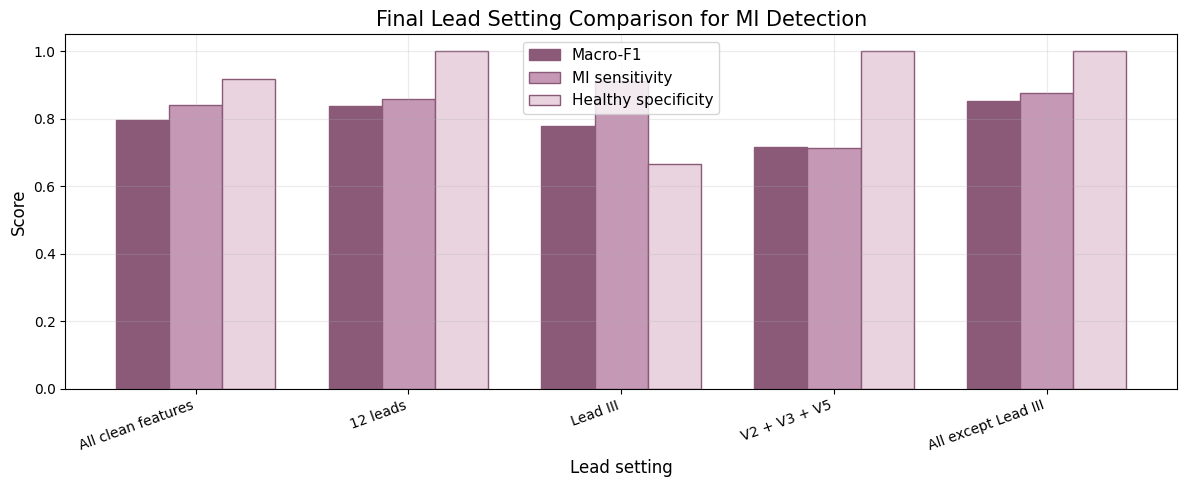

Saved: d:\HUST\ET4248E - Học máy trong y tế\Final Project\results\figures\final_summary\final_lead_setting_comparison.png


WindowsPath('d:/HUST/ET4248E - Học máy trong y tế/Final Project/results/figures/final_summary/final_lead_setting_comparison.png')

In [10]:
plot_df = lead_contribution_summary_df.copy()

x = np.arange(len(plot_df))
width = 0.25

plt.figure(figsize=(12, 5))

plt.bar(
    x - width,
    plot_df["macro_f1"],
    width,
    label="Macro-F1",
    color=PURPLE_DARK,
    edgecolor=PURPLE_DARK
)

plt.bar(
    x,
    plot_df["recall_sensitivity_mi"],
    width,
    label="MI sensitivity",
    color=PURPLE_MAIN,
    edgecolor=PURPLE_DARK
)

plt.bar(
    x + width,
    plot_df["specificity_healthy"],
    width,
    label="Healthy specificity",
    color=PURPLE_LIGHT,
    edgecolor=PURPLE_DARK
)

plt.title("Final Lead Setting Comparison for MI Detection")
plt.xlabel("Lead setting")
plt.ylabel("Score")
plt.xticks(x, plot_df["lead_setting"], rotation=20, ha="right")
plt.ylim(0, 1.05)
plt.legend()
plt.grid(axis="y", alpha=0.25)

save_current_figure("final_lead_setting_comparison.png")

# Comparison with Reference Papers

In [11]:
paper_comparison_df = pd.DataFrame([
    {
        "study": "Paper 1",
        "method": "Morphological features + Random Forest",
        "task": "MI detection",
        "lead_setting": "12 leads",
        "accuracy": 0.9654,
        "sensitivity": 0.9974,
        "specificity": 0.8358,
        "f1_or_macro_f1": 0.9788,
        "metric_note": "F-score reported by paper"
    },
    {
        "study": "Paper 1",
        "method": "Morphological features + Random Forest",
        "task": "MI detection",
        "lead_setting": "6 chest leads",
        "accuracy": 0.9668,
        "sensitivity": np.nan,
        "specificity": np.nan,
        "f1_or_macro_f1": np.nan,
        "metric_note": "Only accuracy used for this lead setting"
    },
    {
        "study": "Paper 2",
        "method": "GA-LSLO + CNN + Lead Attention Module",
        "task": "MI detection",
        "lead_setting": "I, III, aVF, V2, V4, V6",
        "accuracy": 0.9762,
        "sensitivity": 0.9601,
        "specificity": 0.9601,
        "f1_or_macro_f1": 0.9625,
        "metric_note": "Average sensitivity, specificity, and F1 reported by paper"
    },
    {
        "study": "Our study",
        "method": "Handcrafted ECG features + SVM RBF",
        "task": "MI detection",
        "lead_setting": "Full clean features",
        "accuracy": 0.8529,
        "sensitivity": 0.8393,
        "specificity": 0.9167,
        "f1_or_macro_f1": 0.7957,
        "metric_note": "Macro-F1"
    },
    {
        "study": "Our study",
        "method": "Handcrafted ECG features + SVM RBF",
        "task": "MI detection",
        "lead_setting": "Full 12 lead-specific features",
        "accuracy": 0.8824,
        "sensitivity": 0.8571,
        "specificity": 1.0000,
        "f1_or_macro_f1": 0.8365,
        "metric_note": "Macro-F1"
    },
    {
        "study": "Our study",
        "method": "Handcrafted ECG features + SVM RBF",
        "task": "MI detection",
        "lead_setting": "Validation-selected near-12 combination",
        "accuracy": 0.8971,
        "sensitivity": 0.8750,
        "specificity": 1.0000,
        "f1_or_macro_f1": 0.8538,
        "metric_note": "Macro-F1"
    }
])

display(paper_comparison_df)

save_table(paper_comparison_df, "final_comparison_with_reference_papers.csv")

,study,method,task,lead_setting,accuracy,sensitivity,specificity,f1_or_macro_f1,metric_note
0,Paper 1,Morphological features + Random Forest,MI detection,12 leads,0.9654,0.9974,0.8358,0.9788,F-score reported by paper
1,Paper 1,Morphological features + Random Forest,MI detection,6 chest leads,0.9668,NaN,NaN,NaN,Only accuracy used for this lead setting
2,Paper 2,GA-LSLO + CNN + Lead Attention Module,MI detection,"I, III, aVF, V2, V4, V6",0.9762,0.9601,0.9601,0.9625,"Average sensitivity, specificity, and F1 repor..."
3,Our study,Handcrafted ECG features + SVM RBF,MI detection,Full clean features,0.8529,0.8393,0.9167,0.7957,Macro-F1
4,Our study,Handcrafted ECG features + SVM RBF,MI detection,Full 12 lead-specific features,0.8824,0.8571,1.0000,0.8365,Macro-F1
5,Our study,Handcrafted ECG features + SVM RBF,MI detection,Validation-selected near-12 combination,0.8971,0.8750,1.0000,0.8538,Macro-F1


Saved: d:\HUST\ET4248E - Học máy trong y tế\Final Project\results\tables\final_summary\final_comparison_with_reference_papers.csv


WindowsPath('d:/HUST/ET4248E - Học máy trong y tế/Final Project/results/tables/final_summary/final_comparison_with_reference_papers.csv')

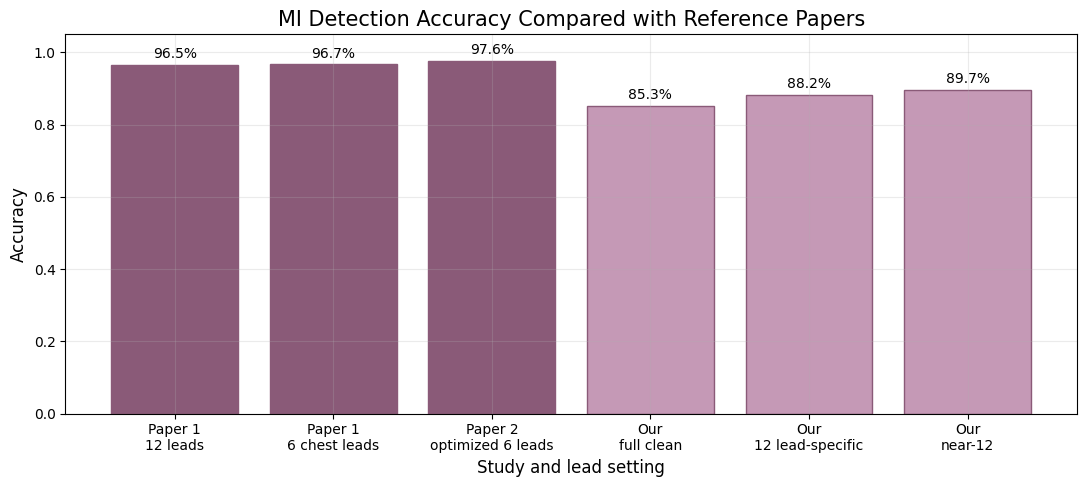

Saved: d:\HUST\ET4248E - Học máy trong y tế\Final Project\results\figures\final_summary\final_accuracy_comparison_with_reference_papers.png


WindowsPath('d:/HUST/ET4248E - Học máy trong y tế/Final Project/results/figures/final_summary/final_accuracy_comparison_with_reference_papers.png')

In [12]:
plot_df = paper_comparison_df.copy()

plot_df["display_name"] = [
    "Paper 1\n12 leads",
    "Paper 1\n6 chest leads",
    "Paper 2\noptimized 6 leads",
    "Our\nfull clean",
    "Our\n12 lead-specific",
    "Our\nnear-12"
]

x = np.arange(len(plot_df))

plt.figure(figsize=(11, 5))

bars = plt.bar(
    x,
    plot_df["accuracy"],
    color=[
        PURPLE_DARK,
        PURPLE_DARK,
        PURPLE_DARK,
        PURPLE_MAIN,
        PURPLE_MAIN,
        PURPLE_MAIN
    ],
    edgecolor=PURPLE_DARK
)

plt.title("MI Detection Accuracy Compared with Reference Papers")
plt.xlabel("Study and lead setting")
plt.ylabel("Accuracy")
plt.xticks(x, plot_df["display_name"])
plt.ylim(0, 1.05)
plt.grid(axis="y", alpha=0.25)

for bar in bars:
    height = bar.get_height()
    plt.text(
        bar.get_x() + bar.get_width() / 2,
        height + 0.01,
        f"{height * 100:.1f}%",
        ha="center",
        va="bottom",
        fontsize=10
    )

save_current_figure("final_accuracy_comparison_with_reference_papers.png")

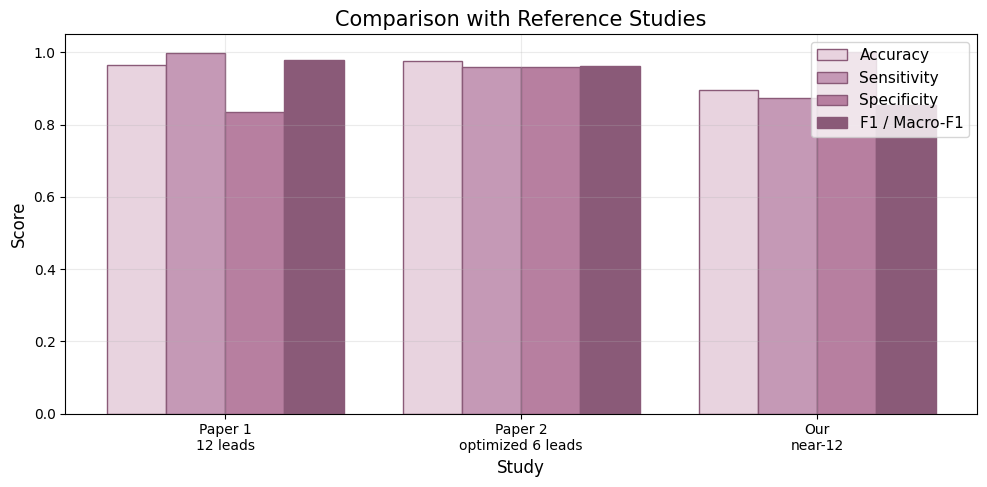

Saved: d:\HUST\ET4248E - Học máy trong y tế\Final Project\results\figures\final_summary\final_multimetric_comparison_with_reference_papers.png


WindowsPath('d:/HUST/ET4248E - Học máy trong y tế/Final Project/results/figures/final_summary/final_multimetric_comparison_with_reference_papers.png')

In [13]:
plot_df = paper_comparison_df[
    paper_comparison_df["study"].isin(["Paper 1", "Paper 2", "Our study"])
].copy()

plot_df = plot_df[
    plot_df["lead_setting"].isin([
        "12 leads",
        "I, III, aVF, V2, V4, V6",
        "Validation-selected near-12 combination"
    ])
].copy()

plot_df["display_name"] = [
    "Paper 1\n12 leads",
    "Paper 2\noptimized 6 leads",
    "Our\nnear-12"
]

x = np.arange(len(plot_df))
width = 0.2

plt.figure(figsize=(10, 5))

plt.bar(
    x - 1.5 * width,
    plot_df["accuracy"],
    width,
    label="Accuracy",
    color=PURPLE_LIGHT,
    edgecolor=PURPLE_DARK
)

plt.bar(
    x - 0.5 * width,
    plot_df["sensitivity"],
    width,
    label="Sensitivity",
    color=PURPLE_MAIN,
    edgecolor=PURPLE_DARK
)

plt.bar(
    x + 0.5 * width,
    plot_df["specificity"],
    width,
    label="Specificity",
    color=PURPLE_MID,
    edgecolor=PURPLE_DARK
)

plt.bar(
    x + 1.5 * width,
    plot_df["f1_or_macro_f1"],
    width,
    label="F1 / Macro-F1",
    color=PURPLE_DARK,
    edgecolor=PURPLE_DARK
)

plt.title("Comparison with Reference Studies")
plt.xlabel("Study")
plt.ylabel("Score")
plt.xticks(x, plot_df["display_name"])
plt.ylim(0, 1.05)
plt.legend()
plt.grid(axis="y", alpha=0.25)

save_current_figure("final_multimetric_comparison_with_reference_papers.png")

In [14]:
# Final Conclusions and Limitations
final_key_findings = {
    "project_direction": "Interpretable MI detection and ECG lead contribution analysis",
    "best_detection_model": "SVM RBF",
    "best_record_level_detection": {
        "setting": "Recall-priority threshold",
        "accuracy": 0.867647,
        "sensitivity": 0.892857,
        "specificity": 0.750000,
        "macro_f1": 0.792049,
        "roc_auc": 0.937500
    },
    "best_balanced_record_level_detection": {
        "setting": "Default SVM RBF decision",
        "accuracy": 0.852941,
        "sensitivity": 0.839286,
        "specificity": 0.916667,
        "macro_f1": 0.795673,
        "roc_auc": 0.937500
    },
    "patient_level_detection": {
        "accuracy": 0.866667,
        "sensitivity": 0.863636,
        "specificity": 0.875000,
        "macro_f1": 0.841270,
        "roc_auc": 0.954545
    },
    "best_lead_setting": {
        "setting": "Validation-selected near-12 combination",
        "removed_lead": "III",
        "accuracy": 0.897059,
        "sensitivity": 0.875000,
        "specificity": 1.000000,
        "macro_f1": 0.853763,
        "roc_auc": 0.949405
    },
    "main_lead_contribution_findings": [
        "Full 12 lead-specific features performed better than full clean features.",
        "Inferior leads achieved performance comparable to the full 12-lead setting.",
        "Lead III was the best individual lead on the test set.",
        "Very small 2-3 lead combinations were less stable.",
        "Near-12 lead combinations preserved or slightly improved performance.",
        "Leave-one-lead-out ablation suggested redundancy among ECG leads."
    ],
    "comparison_with_papers": {
        "paper_1_accuracy": 0.9654,
        "paper_2_accuracy": 0.9762,
        "our_best_accuracy": 0.897059,
        "interpretation": (
            "Our result is lower than the reference papers, mainly because this study used a simpler "
            "interpretable handcrafted-feature and SVM pipeline rather than detailed fiducial-point "
            "morphology with Random Forest or deep learning with GA-based lead selection and attention."
        )
    }
}

summary_path = FINAL_TABLE_DIR / "final_key_findings.json"

with open(summary_path, "w", encoding="utf-8") as f:
    json.dump(final_key_findings, f, indent=4)

print(json.dumps(final_key_findings, indent=4))
print("Saved:", summary_path)

{
    "project_direction": "Interpretable MI detection and ECG lead contribution analysis",
    "best_detection_model": "SVM RBF",
    "best_record_level_detection": {
        "setting": "Recall-priority threshold",
        "accuracy": 0.867647,
        "sensitivity": 0.892857,
        "specificity": 0.75,
        "macro_f1": 0.792049,
        "roc_auc": 0.9375
    },
    "best_balanced_record_level_detection": {
        "setting": "Default SVM RBF decision",
        "accuracy": 0.852941,
        "sensitivity": 0.839286,
        "specificity": 0.916667,
        "macro_f1": 0.795673,
        "roc_auc": 0.9375
    },
    "patient_level_detection": {
        "accuracy": 0.866667,
        "sensitivity": 0.863636,
        "specificity": 0.875,
        "macro_f1": 0.84127,
        "roc_auc": 0.954545
    },
    "best_lead_setting": {
        "setting": "Validation-selected near-12 combination",
        "removed_lead": "III",
        "accuracy": 0.897059,
        "sensitivity": 0.875,
       

In [15]:
print("Notebook 8 completed.")

print("\nSaved final tables in:")
print(FINAL_TABLE_DIR)

print("\nSaved final figures in:")
print(FINAL_FIGURE_DIR)

print("\nRecommended figures for final slides:")
recommended_figures = [
    "final_mi_detection_performance.png",
    "final_lead_setting_comparison.png",
    "final_accuracy_comparison_with_reference_papers.png",
    "final_multimetric_comparison_with_reference_papers.png"
]

for fig in recommended_figures:
    print("-", FINAL_FIGURE_DIR / fig)

Notebook 8 completed.

Saved final tables in:
d:\HUST\ET4248E - Học máy trong y tế\Final Project\results\tables\final_summary

Saved final figures in:
d:\HUST\ET4248E - Học máy trong y tế\Final Project\results\figures\final_summary

Recommended figures for final slides:
- d:\HUST\ET4248E - Học máy trong y tế\Final Project\results\figures\final_summary\final_mi_detection_performance.png
- d:\HUST\ET4248E - Học máy trong y tế\Final Project\results\figures\final_summary\final_lead_setting_comparison.png
- d:\HUST\ET4248E - Học máy trong y tế\Final Project\results\figures\final_summary\final_accuracy_comparison_with_reference_papers.png
- d:\HUST\ET4248E - Học máy trong y tế\Final Project\results\figures\final_summary\final_multimetric_comparison_with_reference_papers.png


In [16]:
# Cross-validation robustness check
cv_robustness_df = pd.DataFrame([
    {
        "metric": "Accuracy",
        "mean": 0.881579,
        "std": 0.027912
    },
    {
        "metric": "MI sensitivity",
        "mean": 0.894060,
        "std": 0.027529
    },
    {
        "metric": "Healthy specificity",
        "mean": 0.824176,
        "std": 0.120065
    },
    {
        "metric": "MI F1-score",
        "mean": 0.925224,
        "std": 0.018022
    },
    {
        "metric": "Macro-F1",
        "mean": 0.818979,
        "std": 0.041819
    },
    {
        "metric": "Balanced accuracy",
        "mean": 0.859118,
        "std": 0.058270
    },
    {
        "metric": "ROC-AUC",
        "mean": 0.932977,
        "std": 0.023161
    }
])

display(cv_robustness_df)

save_table(cv_robustness_df, "final_patient_wise_cross_validation_summary.csv")

,metric,mean,std
0,Accuracy,0.881579,0.027912
1,MI sensitivity,0.894060,0.027529
2,Healthy specificity,0.824176,0.120065
3,MI F1-score,0.925224,0.018022
4,Macro-F1,0.818979,0.041819
5,Balanced accuracy,0.859118,0.058270
6,ROC-AUC,0.932977,0.023161


Saved: d:\HUST\ET4248E - Học máy trong y tế\Final Project\results\tables\final_summary\final_patient_wise_cross_validation_summary.csv


WindowsPath('d:/HUST/ET4248E - Học máy trong y tế/Final Project/results/tables/final_summary/final_patient_wise_cross_validation_summary.csv')

In [17]:
cv_fold_results_df = pd.DataFrame([
    {
        "fold": 1,
        "accuracy": 0.907895,
        "precision_mi": 0.951613,
        "recall_sensitivity_mi": 0.936508,
        "specificity_healthy": 0.769231,
        "f1_mi": 0.944000,
        "macro_f1": 0.842370,
        "balanced_accuracy": 0.852869,
        "roc_auc": 0.899878,
        "tn": 10,
        "fp": 3,
        "fn": 4,
        "tp": 59
    },
    {
        "fold": 2,
        "accuracy": 0.842105,
        "precision_mi": 0.916667,
        "recall_sensitivity_mi": 0.887097,
        "specificity_healthy": 0.642857,
        "f1_mi": 0.901639,
        "macro_f1": 0.750820,
        "balanced_accuracy": 0.764977,
        "roc_auc": 0.934332,
        "tn": 9,
        "fp": 5,
        "fn": 7,
        "tp": 55
    },
    {
        "fold": 3,
        "accuracy": 0.868421,
        "precision_mi": 0.964286,
        "recall_sensitivity_mi": 0.870968,
        "specificity_healthy": 0.857143,
        "f1_mi": 0.915254,
        "macro_f1": 0.810568,
        "balanced_accuracy": 0.864055,
        "roc_auc": 0.922811,
        "tn": 12,
        "fp": 2,
        "fn": 8,
        "tp": 54
    },
    {
        "fold": 4,
        "accuracy": 0.907895,
        "precision_mi": 0.982759,
        "recall_sensitivity_mi": 0.904762,
        "specificity_healthy": 0.923077,
        "f1_mi": 0.942149,
        "macro_f1": 0.858171,
        "balanced_accuracy": 0.913919,
        "roc_auc": 0.959707,
        "tn": 12,
        "fp": 1,
        "fn": 6,
        "tp": 57
    },
    {
        "fold": 5,
        "accuracy": 0.881579,
        "precision_mi": 0.981818,
        "recall_sensitivity_mi": 0.870968,
        "specificity_healthy": 0.928571,
        "f1_mi": 0.923077,
        "macro_f1": 0.832967,
        "balanced_accuracy": 0.899770,
        "roc_auc": 0.948157,
        "tn": 13,
        "fp": 1,
        "fn": 8,
        "tp": 54
    }
])

display(cv_fold_results_df)

save_table(cv_fold_results_df, "final_patient_wise_cross_validation_fold_results.csv")

,fold,accuracy,precision_mi,recall_sensitivity_mi,specificity_healthy,f1_mi,macro_f1,balanced_accuracy,roc_auc,tn,fp,fn,tp
0,1,0.907895,0.951613,0.936508,0.769231,0.944000,0.842370,0.852869,0.899878,10,3,4,59
1,2,0.842105,0.916667,0.887097,0.642857,0.901639,0.750820,0.764977,0.934332,9,5,7,55
2,3,0.868421,0.964286,0.870968,0.857143,0.915254,0.810568,0.864055,0.922811,12,2,8,54
3,4,0.907895,0.982759,0.904762,0.923077,0.942149,0.858171,0.913919,0.959707,12,1,6,57
4,5,0.881579,0.981818,0.870968,0.928571,0.923077,0.832967,0.899770,0.948157,13,1,8,54


Saved: d:\HUST\ET4248E - Học máy trong y tế\Final Project\results\tables\final_summary\final_patient_wise_cross_validation_fold_results.csv


WindowsPath('d:/HUST/ET4248E - Học máy trong y tế/Final Project/results/tables/final_summary/final_patient_wise_cross_validation_fold_results.csv')

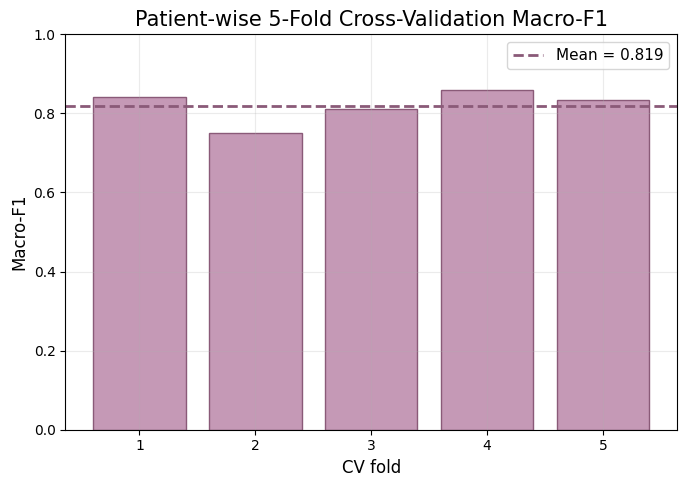

Saved: d:\HUST\ET4248E - Học máy trong y tế\Final Project\results\figures\final_summary\final_patient_wise_cv_macro_f1.png


In [18]:
fig_path = FINAL_FIGURE_DIR / "final_patient_wise_cv_macro_f1.png"

plt.figure(figsize=(7, 5))

plt.bar(
    cv_fold_results_df["fold"].astype(str),
    cv_fold_results_df["macro_f1"],
    color=PURPLE_MAIN,
    edgecolor=PURPLE_DARK
)

mean_macro_f1 = cv_fold_results_df["macro_f1"].mean()

plt.axhline(
    mean_macro_f1,
    color=PURPLE_DARK,
    linestyle="--",
    linewidth=2,
    label=f"Mean = {mean_macro_f1:.3f}"
)

plt.title("Patient-wise 5-Fold Cross-Validation Macro-F1")
plt.xlabel("CV fold")
plt.ylabel("Macro-F1")
plt.ylim(0, 1)
plt.legend()
plt.grid(axis="y", alpha=0.25)

plt.tight_layout()
plt.savefig(fig_path, dpi=300)
plt.show()

print("Saved:", fig_path)

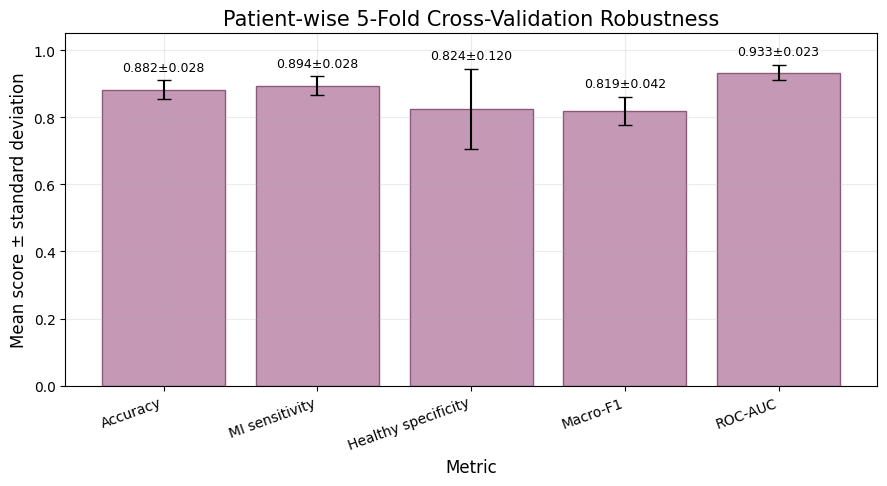

Saved: d:\HUST\ET4248E - Học máy trong y tế\Final Project\results\figures\final_summary\final_patient_wise_cv_mean_std.png


In [19]:
fig_path = FINAL_FIGURE_DIR / "final_patient_wise_cv_mean_std.png"

plot_df = cv_robustness_df[
    cv_robustness_df["metric"].isin([
        "Accuracy",
        "MI sensitivity",
        "Healthy specificity",
        "Macro-F1",
        "ROC-AUC"
    ])
].copy()

plt.figure(figsize=(9, 5))

plt.bar(
    plot_df["metric"],
    plot_df["mean"],
    yerr=plot_df["std"],
    capsize=5,
    color=PURPLE_MAIN,
    edgecolor=PURPLE_DARK
)

plt.title("Patient-wise 5-Fold Cross-Validation Robustness")
plt.xlabel("Metric")
plt.ylabel("Mean score ± standard deviation")
plt.ylim(0, 1.05)
plt.xticks(rotation=20, ha="right")
plt.grid(axis="y", alpha=0.25)

for i, row in plot_df.reset_index(drop=True).iterrows():
    plt.text(
        i,
        row["mean"] + row["std"] + 0.02,
        f"{row['mean']:.3f}±{row['std']:.3f}",
        ha="center",
        va="bottom",
        fontsize=9
    )

plt.tight_layout()
plt.savefig(fig_path, dpi=300)
plt.show()

print("Saved:", fig_path)